In [1]:
import os
import joblib
import pandas as pd
from tqdm import tqdm

from lime.lime_tabular import LimeTabularExplainer
from dotenv import load_dotenv
from xgboost import XGBClassifier

load_dotenv()
os.chdir("..")

MODELDIR = os.getenv("MODELDIR")
DATADIR = os.getenv("DATADIR")

xgb = XGBClassifier()
xgb.load_model(f"{MODELDIR}/xgb_model.ubj")
X_test, y_test = joblib.load(f"{DATADIR}/test_data.pkl")
X_train_bal, y_train_bal = joblib.load(f"{DATADIR}/train_data.pkl")

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

os.makedirs("notebooks/output", exist_ok=True)

print(X_test.shape)


(294, 44)


In [2]:
explainer = LimeTabularExplainer(
    training_data=X_train_bal.values,
    feature_names=X_train_bal.columns.tolist(),
    class_names=["Stayed", "Left"],
    mode="classification",
    random_state=42,
    discretize_continuous=True,
)

In [3]:
lime_weights = []

for i in tqdm(range(len(X_test))):
    exp = explainer.explain_instance(
        data_row=X_test.values[i],
        predict_fn=xgb.predict_proba,
        num_features=len(X_train_bal.columns),
        num_samples=8000,
    )
    weights = dict(exp.as_list())
    lime_weights.append(weights)

lime_weights_df = pd.DataFrame(lime_weights).fillna(0)

lime_global = lime_weights_df.abs().mean().sort_values(ascending=False)
print(lime_global.head(10))

100%|██████████| 294/294 [00:39<00:00,  7.43it/s]

OverTime_Yes <= 0.00                        0.163220
BusinessTravel_Travel_Frequently <= 0.00    0.078090
JobRole_Research Scientist <= 0.00          0.065546
NumCompaniesWorked <= 1.00                  0.062449
0.00 < OverTime_Yes <= 1.00                 0.056844
StockOptionLevel <= 0.00                    0.054316
JobRole_Sales Representative <= 0.00        0.052750
EnvironmentSatisfaction <= 2.00             0.052626
JobRole_Laboratory Technician <= 0.00       0.048206
2.00 < WorkLifeBalance <= 3.00              0.047234
dtype: float64


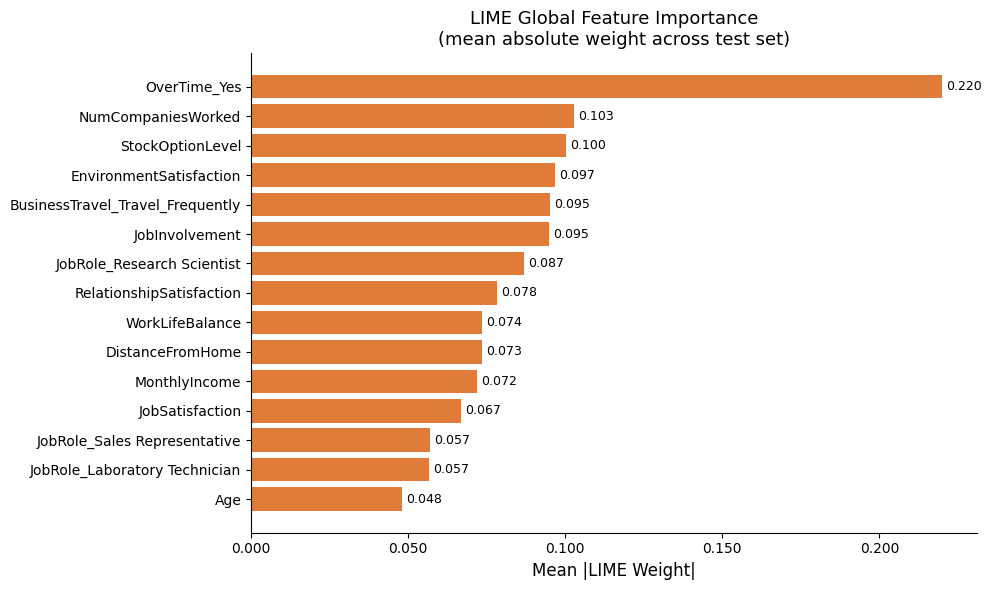

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re

# Strip LIME discretization ranges from column names for global aggregation
def strip_range(col):
    m = re.match(r"(?:[\d.\-]+ < )?(.+?)(?:\s*[<>=]+\s*[\d.\-]+)?$", col)
    return m.group(1).strip() if m else col

clean_df = lime_weights_df.copy()
clean_df.columns = [strip_range(c) for c in clean_df.columns]

# Group by original feature name (sum absolute weights for discretized bins)
lime_global = clean_df.abs().T.groupby(level=0).sum().T.mean().sort_values(ascending=False)

top_n = 15
lime_global_top = lime_global.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    y=lime_global_top.index[::-1],
    width=lime_global_top.values[::-1],
    color="#E07B39",
)

ax.set_xlabel("Mean |LIME Weight|", fontsize=12)
ax.set_title("LIME Global Feature Importance\n(mean absolute weight across test set)", fontsize=13)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("notebooks/output/lime/lime_global_feature_importance.png", bbox_inches="tight", dpi=150)
plt.show()

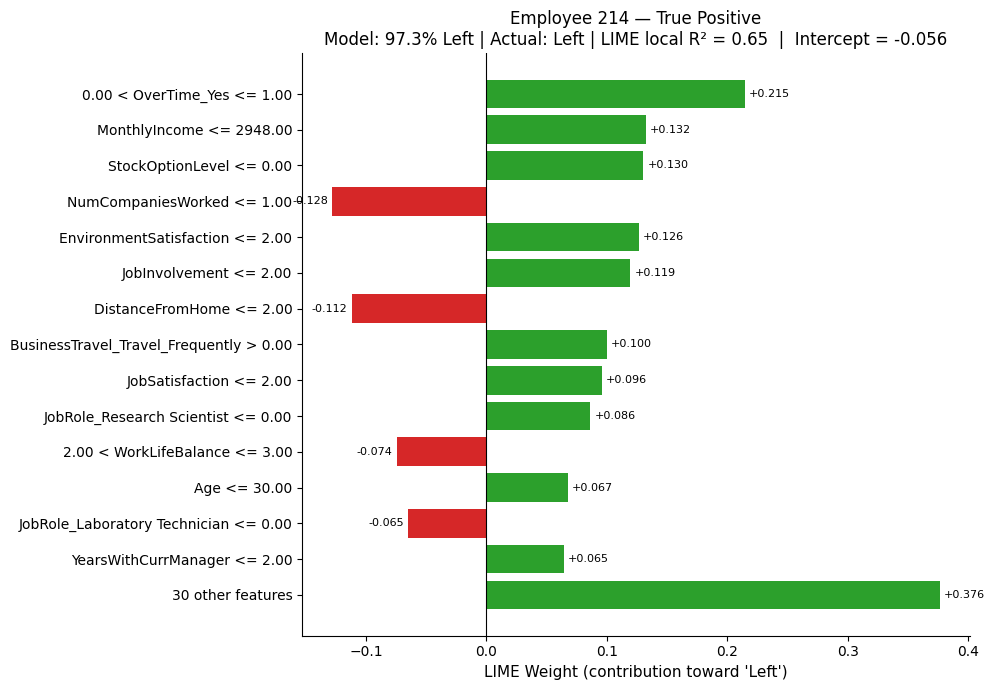

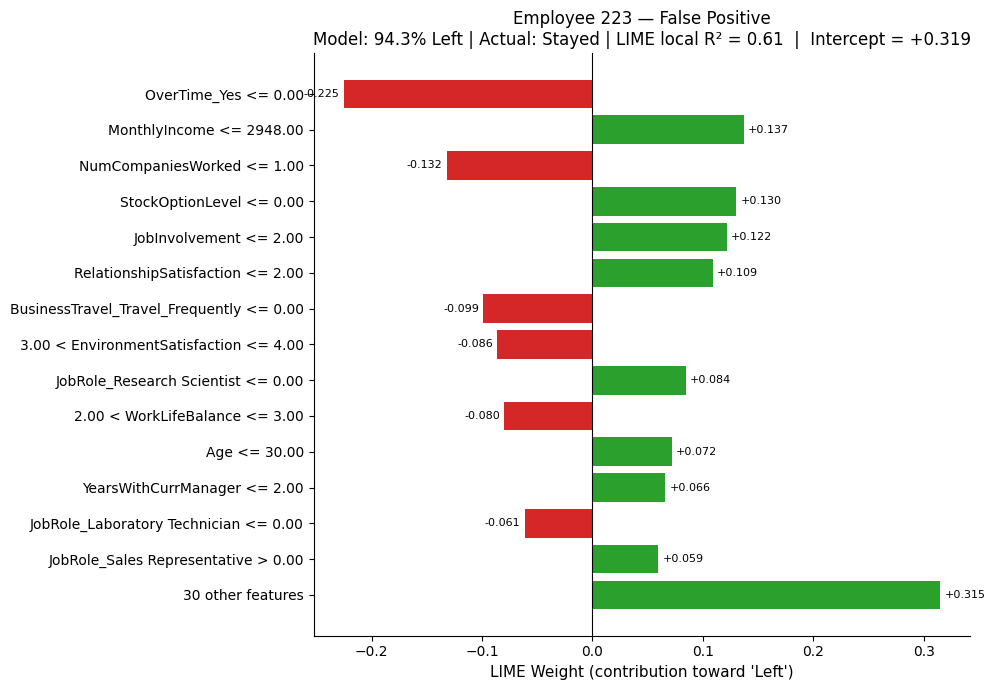

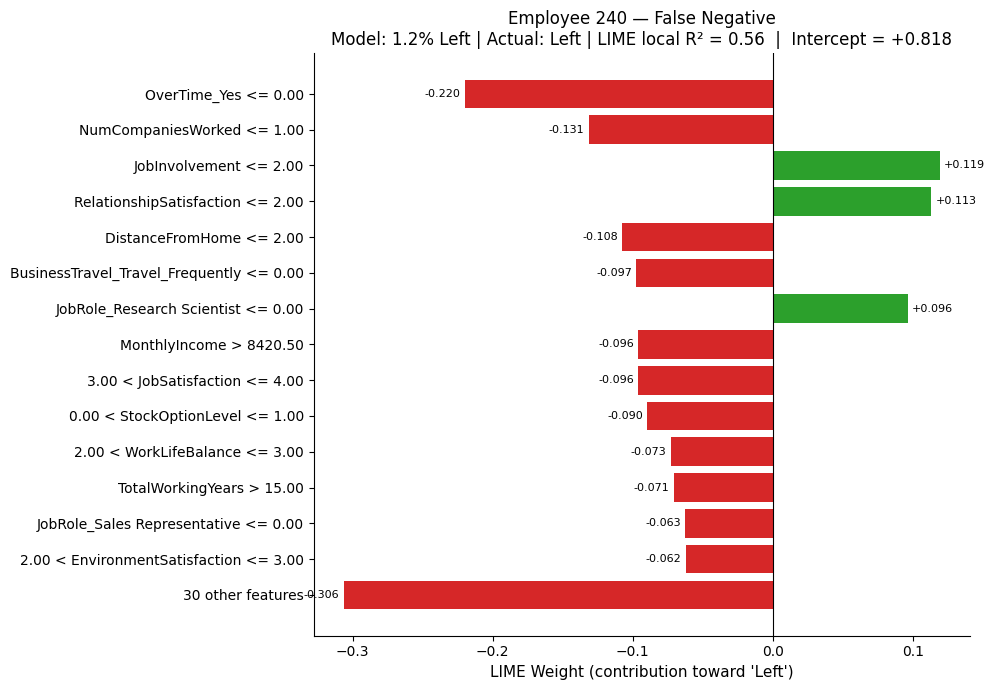

In [5]:
case_studies = [
    {"idx": 214, "label": "True Positive",  "predicted": "Left",   "actual": "Left"},
    {"idx": 223, "label": "False Positive", "predicted": "Left",   "actual": "Stayed"},
    {"idx": 240, "label": "False Negative", "predicted": "Stayed", "actual": "Left"},
]

for case in case_studies:
    idx = case["idx"]

    exp = explainer.explain_instance(
        data_row=X_test.values[idx],
        predict_fn=xgb.predict_proba,
        num_features=len(X_train_bal.columns),
        num_samples=8000,
    )

    prob_stayed, prob_left = exp.predict_proba
    r2 = exp.score

    # Get all weights for class "Left" (label=1)
    weights = dict(exp.as_list(label=1))
    intercept = exp.intercept[1]

    # Sort by absolute value, take top 14
    sorted_feats = sorted(weights.items(), key=lambda x: abs(x[1]), reverse=True)
    top_feats = sorted_feats[:14]
    remaining = sorted_feats[14:]

    # Aggregate the remaining features into one bar
    other_sum = sum(v for _, v in remaining)

    # Build plot data: top features + "other features"
    labels = [f for f, _ in top_feats]
    values = [v for _, v in top_feats]
    labels.append(f"{len(remaining)} other features")
    values.append(other_sum)

    # Reverse for horizontal bar chart (top = most important)
    labels = labels[::-1]
    values = values[::-1]

    colors = ["#2ca02c" if v > 0 else "#d62728" for v in values]

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(labels, values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.bar_label(bars, fmt="%+.3f", padding=3, fontsize=8)
    ax.set_xlabel("LIME Weight (contribution toward 'Left')", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)

    ax.set_title(
        f"Employee {idx} — {case['label']}\n"
        f"Model: {prob_left:.1%} Left | Actual: {case['actual']} | "
        f"LIME local R² = {r2:.2f}  |  Intercept = {intercept:+.3f}",
        fontsize=12,
    )

    plt.tight_layout()
    filename = f"lime_local_emp{idx}_{case['label'].lower().replace(' ', '_')}.png"
    plt.savefig(f"notebooks/output/lime/{filename}", bbox_inches="tight", dpi=150)
    plt.show()

---
## Confronto SHAP vs LIME

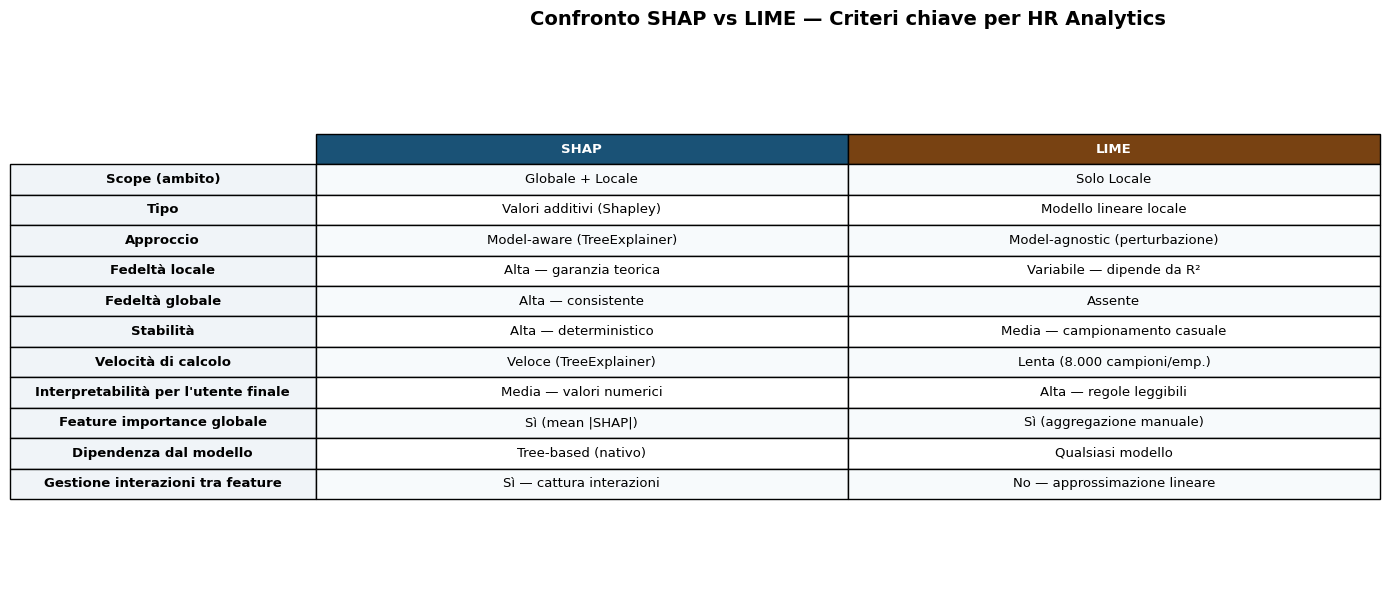

                                                             SHAP                            LIME
Criterio                                                                                         
Scope (ambito)                                   Globale + Locale                     Solo Locale
Tipo                                    Valori additivi (Shapley)          Modello lineare locale
Approccio                             Model-aware (TreeExplainer)  Model-agnostic (perturbazione)
Fedeltà locale                            Alta — garanzia teorica       Variabile — dipende da R²
Fedeltà globale                                Alta — consistente                         Assente
Stabilità                                   Alta — deterministico   Media — campionamento casuale
Velocità di calcolo                        Veloce (TreeExplainer)     Lenta (8.000 campioni/emp.)
Interpretabilità per l'utente finale      Media — valori numerici         Alta — regole leggibili
Feature importance g

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

comparison = {
    "Criterio": [
        "Scope (ambito)",
        "Tipo",
        "Approccio",
        "Fedeltà locale",
        "Fedeltà globale",
        "Stabilità",
        "Velocità di calcolo",
        "Interpretabilità per l'utente finale",
        "Feature importance globale",
        "Dipendenza dal modello",
        "Gestione interazioni tra feature",
    ],
    "SHAP": [
        "Globale + Locale",
        "Valori additivi (Shapley)",
        "Model-aware (TreeExplainer)",
        "Alta — garanzia teorica",
        "Alta — consistente",
        "Alta — deterministico",
        "Veloce (TreeExplainer)",
        "Media — valori numerici",
        "Sì (mean |SHAP|)",
        "Tree-based (nativo)",
        "Sì — cattura interazioni",
    ],
    "LIME": [
        "Solo Locale",
        "Modello lineare locale",
        "Model-agnostic (perturbazione)",
        "Variabile — dipende da R²",
        "Assente",
        "Media — campionamento casuale",
        "Lenta (8.000 campioni/emp.)",
        "Alta — regole leggibili",
        "Sì (aggregazione manuale)",
        "Qualsiasi modello",
        "No — approssimazione lineare",
    ],
}

df = pd.DataFrame(comparison).set_index("Criterio")

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    rowLabels=df.index,
    colLabels=df.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.6)

# Style header row
for col_idx in range(len(df.columns)):
    cell = table[0, col_idx]
    cell.set_facecolor("#1E3A5F")
    cell.set_text_props(color="white", fontweight="bold")

# Style row labels
for row_idx in range(1, len(df) + 1):
    cell = table[row_idx, -1]
    cell.set_facecolor("#F0F4F8")
    cell.set_text_props(fontweight="bold")

# Alternate row background
for row_idx in range(1, len(df) + 1):
    bg = "#FFFFFF" if row_idx % 2 == 0 else "#F7FAFC"
    for col_idx in range(len(df.columns)):
        table[row_idx, col_idx].set_facecolor(bg)

# Color SHAP column (col 0) and LIME column (col 1) headers
table[0, 0].set_facecolor("#1A5276")
table[0, 1].set_facecolor("#784212")

ax.set_title(
    "Confronto SHAP vs LIME — Criteri chiave per HR Analytics",
    fontsize=14, fontweight="bold", pad=20,
)

plt.tight_layout()
plt.savefig("notebooks/output/shap_vs_lime_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

print(df.to_string())